<h1 style="text-align:center;">Clean and Explore 2024 Presidential Election Data in California</h1>

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
print(gpd.__version__)

1.1.3


California Population Data:

https://www.census.gov/data/tables/time-series/demo/popest/2020s-counties-total.html

California 2024 Presidential Election Results and Voter Participation Data:

https://www.sos.ca.gov/elections/prior-elections/statewide-election-results/general-election-nov-5-2024/statement-vote

# Import, Clean and Inspect Population Data

In [17]:
ca_pop_df = pd.read_excel("data/co-est2025-pop-06.xlsx", header=3)
print(ca_pop_df.head())
print(ca_pop_df.tail(10))
print(ca_pop_df.dtypes)
print(ca_pop_df["Unnamed: 0"].unique())

                    Unnamed: 0  Unnamed: 1        2020        2021  \
0                   California  39555703.0  39527808.0  39152927.0   
1  .Alameda County, California   1682246.0   1680489.0   1644275.0   
2   .Alpine County, California      1178.0      1180.0      1194.0   
3   .Amador County, California     40487.0     40567.0     41225.0   
4    .Butte County, California    211629.0    210204.0    206353.0   

         2022        2023        2024        2025  
0  39125347.0  39181667.0  39364774.0  39355309.0  
1   1633138.0   1633055.0   1636624.0   1636630.0  
2      1149.0      1105.0      1086.0      1043.0  
3     41465.0     41783.0     41974.0     41876.0  
4    207312.0    207286.0    208586.0    209211.0  
                                           Unnamed: 0  Unnamed: 1      2020  \
55                       .Tuolumne County, California     55612.0   55369.0   
56                        .Ventura County, California    844358.0  843793.0   
57                           .

In [18]:
# drop first row which is total population of the state
ca_pop_df = ca_pop_df.drop(ca_pop_df.index[0])

# drop last 6 rows which are text
ca_pop_df = ca_pop_df.iloc[:-6]

# drop all columns besides county name and population in 2024
pop_columns_to_drop = [1,2,3,4,5,7]
ca_pop_df = ca_pop_df.drop(columns=ca_pop_df.columns[pop_columns_to_drop])

# rename columns to 'county' and 'population'
ca_pop_df.columns = ['county', 'population']

# remove ' County, California' from county names
ca_pop_df['county'] = ca_pop_df['county'].str.replace(' County, California', '')

# remove period at before county name
ca_pop_df['county'] = ca_pop_df['county'].str.lstrip('.')

# convert population counts from float64 to integers
ca_pop_df['population'] = ca_pop_df['population'].astype('int64')

print(ca_pop_df.head())
print(ca_pop_df.tail())

      county  population
1    Alameda     1636624
2     Alpine        1086
3     Amador       41974
4      Butte      208586
5  Calaveras       46496
      county  population
54    Tulare      483851
55  Tuolumne       54185
56   Ventura      833431
57      Yolo      223260
58      Yuba       87441


In [19]:
print(f"-------------------------- Check for Null Values -------------------------")
print(ca_pop_df.isna().sum())
print()
print(f"---------------------------- Check Data Types ----------------------------")
print(ca_pop_df.dtypes)
print()
print(f"--------------------------- Check County Entries -------------------------")
print(ca_pop_df["county"].unique())

-------------------------- Check for Null Values -------------------------
county        0
population    0
dtype: int64

---------------------------- Check Data Types ----------------------------
county        object
population     int64
dtype: object

--------------------------- Check County Entries -------------------------
['Alameda' 'Alpine' 'Amador' 'Butte' 'Calaveras' 'Colusa' 'Contra Costa'
 'Del Norte' 'El Dorado' 'Fresno' 'Glenn' 'Humboldt' 'Imperial' 'Inyo'
 'Kern' 'Kings' 'Lake' 'Lassen' 'Los Angeles' 'Madera' 'Marin' 'Mariposa'
 'Mendocino' 'Merced' 'Modoc' 'Mono' 'Monterey' 'Napa' 'Nevada' 'Orange'
 'Placer' 'Plumas' 'Riverside' 'Sacramento' 'San Benito' 'San Bernardino'
 'San Diego' 'San Francisco' 'San Joaquin' 'San Luis Obispo' 'San Mateo'
 'Santa Barbara' 'Santa Clara' 'Santa Cruz' 'Shasta' 'Sierra' 'Siskiyou'
 'Solano' 'Sonoma' 'Stanislaus' 'Sutter' 'Tehama' 'Trinity' 'Tulare'
 'Tuolumne' 'Ventura' 'Yolo' 'Yuba']


In [20]:
print(f"----------- Descriptive Statistics -----------")
ca_pop_df.describe()

----------- Descriptive Statistics -----------


,population
count,5.800000e+01
mean,6.787030e+05
std,1.435255e+06
min,1.086000e+03
25%,4.841825e+04
50%,1.875710e+05
75%,6.948132e+05
max,9.748868e+06


# Import, Clean and Inspect 2024 Presidential Election Voting Results Data

In [2]:
ca_votes_df = pd.read_excel("data/ca_president_election_results_2024.xlsx", header=[0])
print(ca_votes_df.head())
print(ca_votes_df.tail())

  Unnamed: 0 Kamala D.\nHarris Donald J.\nTrump Robert F. \nKennedy Jr.  \
0        NaN               DEM              REP                      AI   
1    Alameda            499551           140789                    6786   
2    Percent             74.6%            21.0%                    1.0%   
3        NaN               NaN              NaN                     NaN   
4     Alpine               479              243                       7   

  Jill\nStein Chase\nOliver Claudia\nDe la Cruz Peter\nSonski  
0         GRN           LIB                  PF         (W/I)  
1       13916          2524                6234           107  
2        2.1%          0.4%                0.9%          0.0%  
3         NaN           NaN                 NaN           NaN  
4           5             2                   2             0  
       Unnamed: 0 Kamala D.\nHarris Donald J.\nTrump Robert F. \nKennedy Jr.  \
172          Yuba             10725            18491                     469   
173  

In [3]:
for val in ca_votes_df['Unnamed: 0'].unique():
    print(repr(val))

nan
'Alameda'
'  Percent'
'Alpine'
'Amador'
'Butte'
'Calaveras'
'Colusa'
'Contra Costa'
'Del Norte'
'El Dorado'
'Fresno'
'Glenn'
'Humboldt'
'Imperial'
'Inyo'
'Kern'
'Kings'
'Lake'
'Lassen'
'Los Angeles'
'Madera'
'Marin'
'Mariposa'
'Mendocino'
'Merced'
'Modoc'
'Mono'
'Monterey'
'Napa'
'Nevada'
'Orange'
'Placer'
'Plumas'
'Riverside'
'Sacramento'
'San Benito'
'San Bernardino'
'San Diego'
'San Francisco'
'San Joaquin'
'San Luis Obispo'
'San Mateo'
'Santa Barbara'
'Santa Clara'
'Santa Cruz'
'Shasta'
'Sierra'
'Siskiyou'
'Solano'
'Sonoma'
'Stanislaus'
'Sutter'
'Tehama'
'Trinity'
'Tulare'
'Tuolumne'
'Ventura'
'Yolo'
'Yuba'
'State Totals'


In [4]:
# Remove rows where the row position number divided by 3 starting with row 0 (rows with only NaN)
ca_votes_df = ca_votes_df[ca_votes_df.reset_index(drop=True).index % 3 != 0]

# Remove last 2 rows which is for State Totals
ca_votes_df = ca_votes_df.iloc[:-2].reset_index(drop=True)

In [5]:
print(f"---------------- Check Data Types ------------------")
print(ca_votes_df.dtypes)
print()
print(f"--------------- Check for Null Values --------------")
print(ca_votes_df.isna().sum())

---------------- Check Data Types ------------------
Unnamed: 0                 object
Kamala D.\nHarris          object
Donald J.\nTrump           object
Robert F. \nKennedy Jr.    object
Jill\nStein                object
Chase\nOliver              object
Claudia\nDe la Cruz        object
Peter\nSonski              object
dtype: object

--------------- Check for Null Values --------------
Unnamed: 0                 0
Kamala D.\nHarris          0
Donald J.\nTrump           0
Robert F. \nKennedy Jr.    0
Jill\nStein                0
Chase\nOliver              0
Claudia\nDe la Cruz        0
Peter\nSonski              3
dtype: int64


In [7]:
# Imput NaN entries with 0
ca_votes_df.fillna(0, inplace=True)
print(ca_votes_df.isna().sum())

Unnamed: 0                 0
Kamala D.\nHarris          0
Donald J.\nTrump           0
Robert F. \nKennedy Jr.    0
Jill\nStein                0
Chase\nOliver              0
Claudia\nDe la Cruz        0
Peter\nSonski              0
dtype: int64


## Reshape Election Results Dataset
Each county is represented by two rows, the first row is labeled with the county name and includes counts. The second row is labeled 'percent' for each county and includes percent of votes for each candidate. The data will have to be reshaped so each county is represented by one row.

In [8]:
# Reshape data so each county is represented by a single row
# Identify and separate the county rows and the percentage rows
county_rows = ca_votes_df['Unnamed: 0'] != '  Percent'
counts = ca_votes_df[county_rows].reset_index(drop=True)
percents = ca_votes_df[~county_rows].reset_index(drop=True)   

# Rename percentage columns
candidate_cols = counts.columns[1:]
percents = percents.drop(columns=['Unnamed: 0'])
percents.columns = [f"{c}_percent" for c in candidate_cols]

ca_votes_df = pd.concat(
    [
        counts.reset_index(drop=True),
        percents.reset_index(drop=True)
    ],
    axis=1
)

# Convert percents to numeric 
percent_cols = [c for c in ca_votes_df.columns if c.endswith('_percent') and c not in ['county']]

for c in percent_cols:
    ca_votes_df[c] = (
        ca_votes_df[c]
        .str.rstrip('%')
        .astype(float)
    )

# Convert counts to numeric (they are objects)
counts_cols = []
for c in ca_votes_df.columns:
    if c == 'Unnamed: 0' or c.endswith('_percent'):
        continue
    else:
        counts_cols.append(c)

for c in counts_cols:
    ca_votes_df[c] = (ca_votes_df[c].astype(int))
   

In [9]:
for val in ca_votes_df['Unnamed: 0'].unique():
    print(repr(val))

'Alameda'
'Alpine'
'Amador'
'Butte'
'Calaveras'
'Colusa'
'Contra Costa'
'Del Norte'
'El Dorado'
'Fresno'
'Glenn'
'Humboldt'
'Imperial'
'Inyo'
'Kern'
'Kings'
'Lake'
'Lassen'
'Los Angeles'
'Madera'
'Marin'
'Mariposa'
'Mendocino'
'Merced'
'Modoc'
'Mono'
'Monterey'
'Napa'
'Nevada'
'Orange'
'Placer'
'Plumas'
'Riverside'
'Sacramento'
'San Benito'
'San Bernardino'
'San Diego'
'San Francisco'
'San Joaquin'
'San Luis Obispo'
'San Mateo'
'Santa Barbara'
'Santa Clara'
'Santa Cruz'
'Shasta'
'Sierra'
'Siskiyou'
'Solano'
'Sonoma'
'Stanislaus'
'Sutter'
'Tehama'
'Trinity'
'Tulare'
'Tuolumne'
'Ventura'
'Yolo'
'Yuba'


## Rename and Condense Columns in 2024 Election Results Dataset

In [10]:
print(ca_votes_df.columns)

Index(['Unnamed: 0', 'Kamala D.\nHarris', 'Donald J.\nTrump',
       'Robert F. \nKennedy Jr.', 'Jill\nStein', 'Chase\nOliver',
       'Claudia\nDe la Cruz', 'Peter\nSonski', 'Kamala D.\nHarris_percent',
       'Donald J.\nTrump_percent', 'Robert F. \nKennedy Jr._percent',
       'Jill\nStein_percent', 'Chase\nOliver_percent',
       'Claudia\nDe la Cruz_percent', 'Peter\nSonski_percent'],
      dtype='object')


In [11]:
# Rename 'Unnamed: 0' to 'county'
ca_votes_df = ca_votes_df.rename(columns={'Unnamed: 0': 'county'})

# Rename major party columns to 'democrate' and 'republican'
ca_votes_df = ca_votes_df.rename(
    columns={
        'Kamala D.\nHarris': 'counts democrat', 
        'Donald J.\nTrump': 'counts republican',
        'Kamala D.\nHarris_percent': 'percent democrat',
        'Donald J.\nTrump_percent': 'percent republican'
    }
)

# Condense minor parties into two columns 'counts other' and 'percent other'
other_counts = [
    'Robert F. \nKennedy Jr.',
    'Jill\nStein',
    'Chase\nOliver',
    'Claudia\nDe la Cruz',
    'Peter\nSonski'
]

other_percent = [
    'Robert F. \nKennedy Jr._percent',
    'Jill\nStein_percent', 
    'Chase\nOliver_percent', 
    'Claudia\nDe la Cruz_percent',
    'Peter\nSonski_percent'
]

# Sum defined columns and drop original columns
ca_votes_df['counts other'] = ca_votes_df[other_counts].sum(axis=1)

ca_votes_df['percent other'] = ca_votes_df[other_percent].sum(axis=1)

ca_votes_df.drop(
    columns=other_counts + other_percent,
    inplace=True
)

# Reorder columns
ca_votes_df = ca_votes_df[
    [
        'county', 
        'counts democrat', 
        'percent democrat', 
        'counts republican', 
        'percent republican', 
        'counts other', 
        'percent other'
    ]
]


In [12]:
print(ca_votes_df.head())
print(ca_votes_df.tail())

      county  counts democrat  percent democrat  counts republican  \
0    Alameda           499551              74.6             140789   
1     Alpine              479              64.9                243   
2     Amador             7783              34.7              14018   
3      Butte            44228              46.8              47179   
4  Calaveras             9181              34.7              16625   

   percent republican  counts other  percent other  
0                21.0         29567            4.4  
1                32.9            16            2.2  
2                62.6           602            2.7  
3                49.9          3149            3.2  
4                62.8           674            2.6  
      county  counts democrat  percent democrat  counts republican  \
53    Tulare            53221              38.5              81854   
54  Tuolumne            10909              37.9              17210   
55   Ventura           217424              56.1    

In [13]:
for val in ca_votes_df['county'].unique():
    print(repr(val))

'Alameda'
'Alpine'
'Amador'
'Butte'
'Calaveras'
'Colusa'
'Contra Costa'
'Del Norte'
'El Dorado'
'Fresno'
'Glenn'
'Humboldt'
'Imperial'
'Inyo'
'Kern'
'Kings'
'Lake'
'Lassen'
'Los Angeles'
'Madera'
'Marin'
'Mariposa'
'Mendocino'
'Merced'
'Modoc'
'Mono'
'Monterey'
'Napa'
'Nevada'
'Orange'
'Placer'
'Plumas'
'Riverside'
'Sacramento'
'San Benito'
'San Bernardino'
'San Diego'
'San Francisco'
'San Joaquin'
'San Luis Obispo'
'San Mateo'
'Santa Barbara'
'Santa Clara'
'Santa Cruz'
'Shasta'
'Sierra'
'Siskiyou'
'Solano'
'Sonoma'
'Stanislaus'
'Sutter'
'Tehama'
'Trinity'
'Tulare'
'Tuolumne'
'Ventura'
'Yolo'
'Yuba'


In [14]:
print(f"-------------------------- Check for Null Values -------------------------")
print(ca_votes_df.isna().sum())
print()
print(f"---------------------------- Check Data Types ----------------------------")
print(ca_votes_df.dtypes)
print()
print(f"--------------------------- Check County Entries -------------------------")
print(ca_votes_df["county"].unique())

-------------------------- Check for Null Values -------------------------
county                0
counts democrat       0
percent democrat      0
counts republican     0
percent republican    0
counts other          0
percent other         0
dtype: int64

---------------------------- Check Data Types ----------------------------
county                 object
counts democrat         int64
percent democrat      float64
counts republican       int64
percent republican    float64
counts other            int64
percent other         float64
dtype: object

--------------------------- Check County Entries -------------------------
['Alameda' 'Alpine' 'Amador' 'Butte' 'Calaveras' 'Colusa' 'Contra Costa'
 'Del Norte' 'El Dorado' 'Fresno' 'Glenn' 'Humboldt' 'Imperial' 'Inyo'
 'Kern' 'Kings' 'Lake' 'Lassen' 'Los Angeles' 'Madera' 'Marin' 'Mariposa'
 'Mendocino' 'Merced' 'Modoc' 'Mono' 'Monterey' 'Napa' 'Nevada' 'Orange'
 'Placer' 'Plumas' 'Riverside' 'Sacramento' 'San Benito' 'San Bernardino'
 'S

In [24]:
print(f"------------------------------------- Descriptive Statistics ------------------------------------")
ca_votes_df.describe()

------------------------------------- Descriptive Statistics ------------------------------------


,counts democrat,percent democrat,counts republican,percent republican,counts other,percent other
count,5.800000e+01,58.000000,5.800000e+01,58.000000,58.000000,58.000000
mean,1.599341e+05,49.941379,1.048568e+05,47.032759,8751.706897,3.000000
std,3.519690e+05,14.564352,1.986924e+05,14.916391,18298.471630,0.551553
min,4.790000e+02,21.800000,2.430000e+02,15.500000,16.000000,2.200000
25%,8.542000e+03,38.250000,1.325275e+04,34.650000,679.750000,2.600000
50%,4.170100e+04,47.650000,2.791100e+04,49.500000,2569.500000,2.950000
75%,1.240232e+05,61.675000,1.007030e+05,59.200000,7840.500000,3.200000
max,2.417109e+06,80.600000,1.189862e+06,75.800000,122118.000000,4.400000


# Import, Clean and Inspect 2024 Presidential Election Voter Participation Data

In [34]:
ca_part_df = pd.read_excel("data/ca_voter_participation_county.xlsx")
print(ca_part_df.head())
print(ca_part_df.tail())

       County  Number of Precincts  Eligible to Register  Registered Voters1   \
0    Alameda*                  570             1,132,323             961,304    
1      Alpine                    5                   993                 954    
2     Amador*                   47                28,571              26,488    
3      Butte*                  132               169,890             125,088    
4  Calaveras*                   25                36,435              33,059    

  Precinct Voters*  Vote-By-Mail Voters  Total Voters   \
0           87,078              595,991       683,069    
1              0**                  749           749    
2            2,297               20,465        22,762    
3            4,014               92,092        96,106    
4            4,567               22,318        26,885    

  Percent of Vote-By-Mail Voters  Turnout Registered  Turnout Eligible   
0                         87.25%              71.06%            60.32%   
1               

In [35]:
print(ca_part_df.columns)

Index([' County ', 'Number of Precincts ', 'Eligible to Register ',
       'Registered Voters1 ', 'Precinct Voters* ', 'Vote-By-Mail Voters ',
       'Total Voters ', 'Percent of Vote-By-Mail Voters ',
       'Turnout Registered ', 'Turnout Eligible '],
      dtype='object')


In [36]:
# Remove white space before and after column names
ca_part_df.columns = ca_part_df.columns.str.strip()
print(ca_part_df.columns)

Index(['County', 'Number of Precincts', 'Eligible to Register',
       'Registered Voters1', 'Precinct Voters*', 'Vote-By-Mail Voters',
       'Total Voters', 'Percent of Vote-By-Mail Voters', 'Turnout Registered',
       'Turnout Eligible'],
      dtype='object')


In [37]:
for val in ca_part_df['County'].unique():
    print(repr(val))
    

'Alameda*\xa0'
'Alpine\xa0'
'Amador*\xa0'
'Butte*\xa0'
'Calaveras*\xa0'
'Colusa\xa0'
'Contra Costa\xa0'
'Del Norte\xa0'
'El Dorado*\xa0'
'Fresno*\xa0'
'Glenn\xa0'
'Humboldt*\xa0'
'Imperial\xa0'
'Inyo\xa0'
'Kern\xa0'
'Kings*\xa0'
'Lake\xa0'
'Lassen\xa0'
'Los Angeles*\xa0'
'Madera*\xa0'
'Marin*\xa0'
'Mariposa*\xa0'
'Mendocino\xa0'
'Merced*\xa0'
'Modoc\xa0'
'Mono\xa0'
'Monterey\xa0'
'Napa*\xa0'
'Nevada*\xa0'
'Orange*\xa0'
'Placer*\xa0'
'Plumas\xa0'
'Riverside*\xa0'
'Sacramento*\xa0'
'San Benito*\xa0'
'San Bernardino\xa0'
'San Diego*\xa0'
'San Francisco\xa0'
'San Joaquin\xa0'
'San Luis Obispo\xa0'
'San Mateo*\xa0'
'Santa Barbara\xa0'
'Santa Clara*\xa0'
'Santa Cruz*\xa0'
'Shasta\xa0'
'Sierra\xa0'
'Siskiyou\xa0'
'Solano\xa0'
'Sonoma*\xa0'
'Stanislaus*\xa0'
'Sutter\xa0'
'Tehama\xa0'
'Trinity\xa0'
'Tulare\xa0'
'Tuolumne*\xa0'
'Ventura*\xa0'
'Yolo*\xa0'
'Yuba\xa0'


In [38]:
# rename 'County' to 'county' to match other datasets
ca_part_df = ca_part_df.rename(columns={'County': 'county'})

# Remove unnecessary caharacters in county names
ca_part_df['county'] = (
    ca_part_df['county']
        .astype(str)
        .str.replace("\xa0", "", regex=False)
        .str.replace("*", "", regex=False)
        .str.strip() 
)
        
for val in ca_part_df['county'].unique():
    print(repr(val))

'Alameda'
'Alpine'
'Amador'
'Butte'
'Calaveras'
'Colusa'
'Contra Costa'
'Del Norte'
'El Dorado'
'Fresno'
'Glenn'
'Humboldt'
'Imperial'
'Inyo'
'Kern'
'Kings'
'Lake'
'Lassen'
'Los Angeles'
'Madera'
'Marin'
'Mariposa'
'Mendocino'
'Merced'
'Modoc'
'Mono'
'Monterey'
'Napa'
'Nevada'
'Orange'
'Placer'
'Plumas'
'Riverside'
'Sacramento'
'San Benito'
'San Bernardino'
'San Diego'
'San Francisco'
'San Joaquin'
'San Luis Obispo'
'San Mateo'
'Santa Barbara'
'Santa Clara'
'Santa Cruz'
'Shasta'
'Sierra'
'Siskiyou'
'Solano'
'Sonoma'
'Stanislaus'
'Sutter'
'Tehama'
'Trinity'
'Tulare'
'Tuolumne'
'Ventura'
'Yolo'
'Yuba'


In [39]:
ca_part_df.rename(columns={
    "Registered Voters1": "Registered Voters",
    "Precinct Voters*": "Precinct Voters",
    "Turnout Registered": "Precent Turnout Registered",
    "Turnout Eligible": "Precent Turnout Eligible"
}, inplace=True)

In [40]:
ca_part_df.dtypes

county                            object
Number of Precincts               object
Eligible to Register              object
Registered Voters                 object
Precinct Voters                   object
Vote-By-Mail Voters               object
Total Voters                      object
Percent of Vote-By-Mail Voters    object
Precent Turnout Registered        object
Precent Turnout Eligible          object
dtype: object

In [41]:
# Convert columns that contain counts to integers and remove punctuation.
count_cols = [
    "Number of Precincts",
    "Eligible to Register",
    "Registered Voters",
    "Precinct Voters",
    "Vote-By-Mail Voters",
    "Total Voters"
]    

for col in count_cols:
    ca_part_df[col] = (
        ca_part_df[col]
            .str.replace(",", "", regex=False)
            .str.replace("**", "", regex=False) # entries of 0 were entered as 0**
            .str.strip()
            .astype(int)
    )

# Convert columns that contain percentages to continuous and remove puctuation
pct_cols = [
    "Percent of Vote-By-Mail Voters",
    "Precent Turnout Registered",
    "Precent Turnout Eligible"
]  

for col in pct_cols:
    ca_part_df[col] = (
        ca_part_df[col]
            .str.replace("%", "", regex=False)
            .astype(float)
    )

In [42]:
print(ca_part_df.head())
print(ca_part_df.tail())

      county  Number of Precincts  Eligible to Register  Registered Voters  \
0    Alameda                  570               1132323             961304   
1     Alpine                    5                   993                954   
2     Amador                   47                 28571              26488   
3      Butte                  132                169890             125088   
4  Calaveras                   25                 36435              33059   

   Precinct Voters  Vote-By-Mail Voters  Total Voters  \
0            87078               595991        683069   
1                0                  749           749   
2             2297                20465         22762   
3             4014                92092         96106   
4             4567                22318         26885   

   Percent of Vote-By-Mail Voters  Precent Turnout Registered  \
0                           87.25                       71.06   
1                          100.00                       78

In [43]:
print(f"-------------------------- Check for Null Values -------------------------")
print(ca_part_df.isna().sum())
print()
print(f"---------------------------- Check Data Types ----------------------------")
print(ca_part_df.dtypes)
print()
print(f"--------------------------- Check County Entries -------------------------")
print(ca_part_df["county"].unique())

-------------------------- Check for Null Values -------------------------
county                            0
Number of Precincts               0
Eligible to Register              0
Registered Voters                 0
Precinct Voters                   0
Vote-By-Mail Voters               0
Total Voters                      0
Percent of Vote-By-Mail Voters    0
Precent Turnout Registered        0
Precent Turnout Eligible          0
dtype: int64

---------------------------- Check Data Types ----------------------------
county                             object
Number of Precincts                 int64
Eligible to Register                int64
Registered Voters                   int64
Precinct Voters                     int64
Vote-By-Mail Voters                 int64
Total Voters                        int64
Percent of Vote-By-Mail Voters    float64
Precent Turnout Registered        float64
Precent Turnout Eligible          float64
dtype: object

--------------------------- Check County 

In [48]:
print(f"----------------------------------------------------------- Descriptive Statistics --------------------------------------------------")
ca_part_df.describe()

----------------------------------------------------------- Descriptive Statistics --------------------------------------------------


,Number of Precincts,Eligible to Register,Registered Voters,Precinct Voters,Vote-By-Mail Voters,Total Voters,Percent of Vote-By-Mail Voters,Precent Turnout Registered,Precent Turnout Eligible
count,58.000000,5.800000e+01,5.800000e+01,5.800000e+01,5.800000e+01,5.800000e+01,58.000000,58.000000,58.000000
mean,427.775862,4.640161e+05,3.895803e+05,5.354597e+04,2.247307e+05,2.782766e+05,86.093103,74.908793,62.043448
std,709.411148,9.819224e+05,8.412104e+05,1.472526e+05,4.293994e+05,5.710883e+05,7.953601,6.337562,8.838074
min,5.000000,9.930000e+02,9.540000e+02,0.000000e+00,7.490000e+02,7.490000e+02,54.610000,60.570000,44.030000
25%,41.000000,3.768175e+04,3.366225e+04,2.609000e+03,2.234875e+04,2.687150e+04,82.875000,70.812500,55.625000
50%,152.000000,1.410080e+05,1.168620e+05,1.235850e+04,7.541550e+04,8.881750e+04,86.130000,76.095000,61.520000
75%,444.500000,4.767262e+05,3.663605e+05,5.042675e+04,2.082050e+05,2.646322e+05,89.887500,79.225000,68.135000
max,3087.000000,6.657487e+06,5.745214e+06,1.060354e+06,2.732752e+06,3.793106e+06,100.000000,85.930000,80.300000


# Join Datasets

## Convert All Column Names to Lowercase and snake_case

In [49]:
for df in [ca_votes_df, ca_part_df, ca_pop_df]:
    df.columns = (
        df.columns
            .str.strip()
            .str.lower()
            .str.replace(" ", "_", regex=False)
            .str.replace("-", "_", regex=False)
    )

# Ensure there is no white space in column name "county"
for df in [ca_votes_df, ca_part_df, ca_pop_df]:
    df["county"] = df["county"].str.strip()

In [50]:
print(ca_votes_df.head())
print(ca_part_df.head())
print(ca_pop_df.head())

      county  counts_democrat  percent_democrat  counts_republican  \
0    Alameda           499551              74.6             140789   
1     Alpine              479              64.9                243   
2     Amador             7783              34.7              14018   
3      Butte            44228              46.8              47179   
4  Calaveras             9181              34.7              16625   

   percent_republican  counts_other  percent_other  
0                21.0         29567            4.4  
1                32.9            16            2.2  
2                62.6           602            2.7  
3                49.9          3149            3.2  
4                62.8           674            2.6  
      county  number_of_precincts  eligible_to_register  registered_voters  \
0    Alameda                  570               1132323             961304   
1     Alpine                    5                   993                954   
2     Amador               

## Merge Datasets and Save

In [51]:
california_voter_data_by_county_2024 = ca_pop_df.merge(ca_votes_df, on="county")
california_voter_data_by_county_2024 = california_voter_data_by_county_2024.merge(ca_part_df, on="county")
california_voter_data_by_county_2024.head()

,county,population,counts_democrat,percent_democrat,counts_republican,percent_republican,counts_other,percent_other,number_of_precincts,eligible_to_register,registered_voters,precinct_voters,vote_by_mail_voters,total_voters,percent_of_vote_by_mail_voters,precent_turnout_registered,precent_turnout_eligible
0,Alameda,1636624,499551,74.6,140789,21.0,29567,4.4,570,1132323,961304,87078,595991,683069,87.25,71.06,60.32
1,Alpine,1086,479,64.9,243,32.9,16,2.2,5,993,954,0,749,749,100.00,78.51,75.43
2,Amador,41974,7783,34.7,14018,62.6,602,2.7,47,28571,26488,2297,20465,22762,89.91,85.93,79.67
3,Butte,208586,44228,46.8,47179,49.9,3149,3.2,132,169890,125088,4014,92092,96106,95.82,76.83,56.57
4,Calaveras,46496,9181,34.7,16625,62.8,674,2.6,25,36435,33059,4567,22318,26885,83.01,81.32,73.79


In [52]:
california_voter_data_by_county_2024.to_csv("data/california_voter_data_by_county_2024.csv", index=False)
california_voter_data_by_county_2024.to_parquet("data/california_voter_data_by_county_2024.parquet", index=False)

# Visualizations

## Map Population Density by County

In [55]:
# Import California county data from U.S. Census 
counties = gpd.read_file("data/tl_2024_us_county/tl_2024_us_county.shp")

# Filter for California (STATEFP = '06')
counties = counties[counties["STATEFP"] == "06"]

counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
8,06,091,00277310,06091,0500000US06091,Sierra,Sierra County,06,H1,G4020,None,None,None,A,2468694578,23299110,+39.5769252,-120.5219926,"POLYGON ((-120.55587 39.50874, -120.55614 39.5..."
324,06,067,00277298,06067,0500000US06067,Sacramento,Sacramento County,06,H1,G4020,472,40900,None,A,2500063005,75323439,+38.4501363,-121.3443291,"POLYGON ((-121.43991 38.25553, -121.44002 38.2..."
328,06,083,00277306,06083,0500000US06083,Santa Barbara,Santa Barbara County,06,H1,G4020,None,42200,None,A,7080874935,2729198796,+34.5366774,-120.0383645,"MULTIPOLYGON (((-120.58226 34.10752, -120.5790..."
345,06,009,01675885,06009,0500000US06009,Calaveras,Calaveras County,06,H1,G4020,None,None,None,A,2641829625,43797225,+38.1910682,-120.5541065,"POLYGON ((-120.6318 38.34603, -120.63066 38.34..."
393,06,111,00277320,06111,0500000US06111,Ventura,Ventura County,06,H1,G4020,348,37100,None,A,4767597024,947364179,+34.3587477,-119.1331453,"MULTIPOLYGON (((-119.63607 33.28071, -119.6348..."


In [56]:
# Merge map data with voter data 
ca_map = counties.merge(
    california_voter_data_by_county_2024,
    left_on="NAME",
    right_on="county",
    how="left"
)

print(len(ca_map))
print(ca_map["county"].isna().sum())

58
0


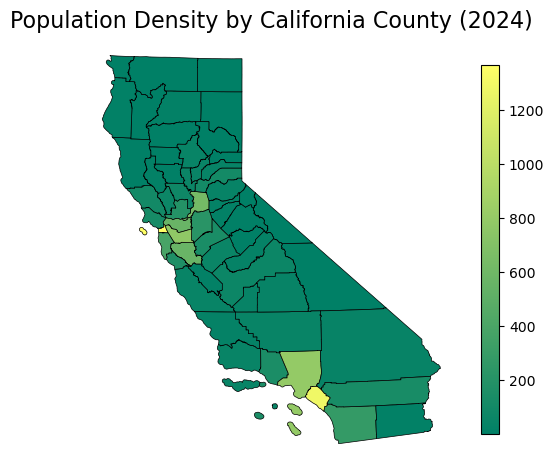

In [63]:
# Convert to lat/lon Coordinate Reference System (crs) for mapping
ca_map = ca_map.to_crs("EPSG:3310")

ca_map["area_sq_km"] = ca_map.geometry.area / 1e6
ca_map["population_density"] = (

    ca_map["population"] / ca_map["area_sq_km"]

)
fig, ax = plt.subplots(figsize=(6, 8))

ca_map.plot(
    column="population_density",
    cmap="summer",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    legend_kwds={"shrink": 0.6},
    ax=ax
)

ax.set_title("Population Density by California County (2024)", fontsize=16)
ax.set_axis_off()

# option to save plot
#plt.savefig("results/california_population_map_2024.png")

plt.show()

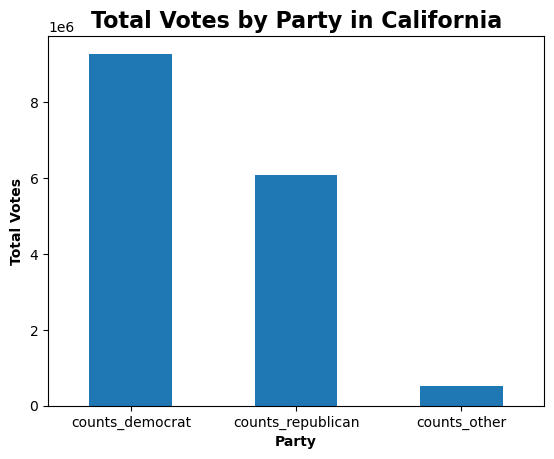

In [54]:
# Examine total number of votes
totals = california_voter_data_by_county_2024[['counts_democrat', 'counts_republican', 'counts_other']].sum()

plt.figure()
totals.plot(kind="bar")

plt.title("Total Votes by Party in California", weight="bold", fontsize=16)
plt.xlabel("Party", weight="bold")
plt.ylabel("Total Votes", weight="bold")

plt.xticks(rotation=0)
# option to save plot
#plt.savefig("results/california_total_votes_2024.png")
plt.show()

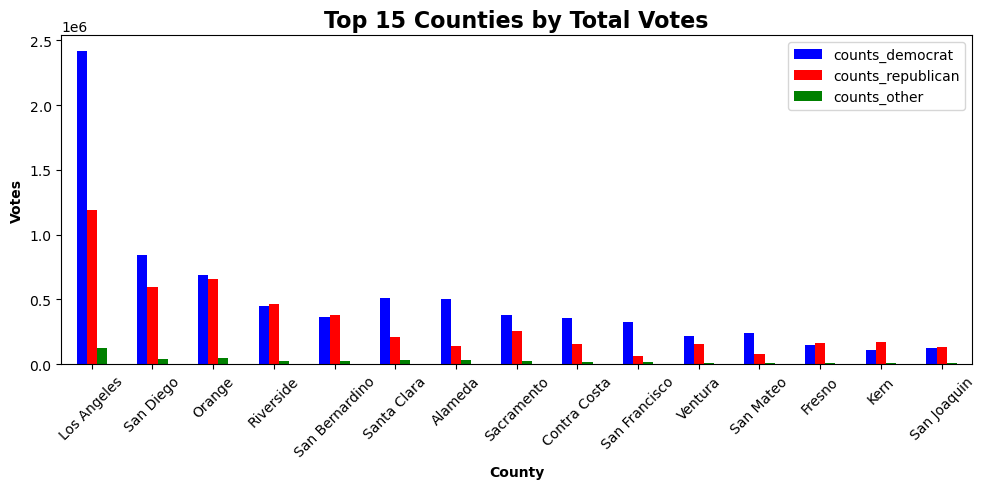

In [65]:
top_counties = california_voter_data_by_county_2024.sort_values("total_voters", ascending=False).head(15)

colors = ["blue", "red", "green"]

top_counties.set_index("county")[["counts_democrat", "counts_republican", "counts_other"]].plot(
    kind="bar", figsize=(10,5), color=colors
)

plt.title("Top 15 Counties by Total Votes", weight="bold", fontsize=16)
plt.xlabel("County", weight="bold")
plt.ylabel("Votes", weight="bold")

plt.xticks(rotation=45)
plt.tight_layout()
# option to save plot
#plt.savefig("results/california_top_counties_total_votes_2024.png")
plt.show()

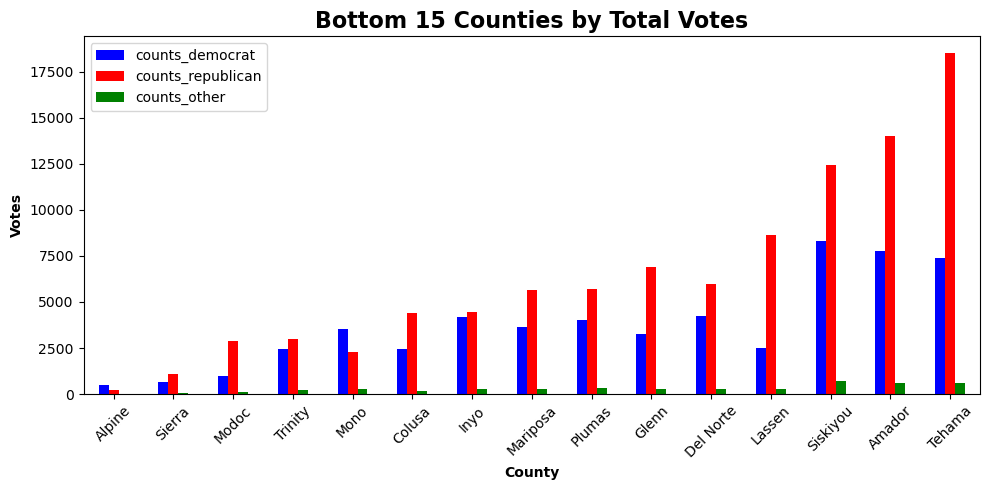

In [67]:
bottom_counties = california_voter_data_by_county_2024.sort_values("total_voters", ascending=True).head(15)

colors = ["blue", "red", "green"]

bottom_counties.set_index("county")[["counts_democrat", "counts_republican", "counts_other"]].plot(
    kind="bar", figsize=(10,5), color=colors
)

plt.title("Bottom 15 Counties by Total Votes", weight="bold", fontsize=16)
plt.xlabel("County", weight="bold")
plt.ylabel("Votes", weight="bold")

plt.xticks(rotation=45)
plt.tight_layout()
# option to save plot
#plt.savefig("results/california_bottom_counties_total_votes_2024.png")
plt.show()